In [ ]:
# ========== 1. IMPORT SEMUA ==========
import tensorflow as tf
import os
import zipfile
import shutil
from google.colab import files
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

print("Step 1: Library OK")


Step 1: Library OK


In [ ]:
# ========== 2. UPLOAD DATASET ==========
print("\nStep 2: Upload file ZIP kau di sini")
uploaded = files.upload()

zip_name = list(uploaded.keys())[0]
with zipfile.ZipFile(zip_name, 'r') as zip_ref:
    zip_ref.extractall('/content/data')
print("Extract selesai")


Step 2: Upload file ZIP kau di sini


Saving dataset_beras.zip to dataset_beras (3).zip
Extract selesai


In [ ]:
# ========== 3. BIKIN STRUKTUR FOLDER OTOMATIS ==========
kelas = ['Good', 'Damaged', 'Immature']
for k in kelas:
    os.makedirs(f'/content/data/{k}', exist_ok=True)

for file in os.listdir('/content/data'):
    file_path = os.path.join('/content/data', file)
    if os.path.isfile(file_path):
        if 'good' in file.lower():
            shutil.move(file_path, f'/content/data/Good/{file}')
        elif 'damaga' in file.lower():
            shutil.move(file_path, f'/content/data/Damaged/{file}')
        elif 'immat' in file.lower():
            shutil.move(file_path, f'/content/data/Immature/{file}')

print("\nStep 3: Hasil pindah file")
for k in kelas:
    print(f"{k}: {len(os.listdir(f'/content/data/{k}'))} foto")


Step 3: Hasil pindah file
Good: 2 foto
Damaged: 2 foto
Immature: 2 foto


In [ ]:
# ========== 4. LOAD DATA ==========
datagen = ImageDataGenerator(rescale=1./255)

train_data = datagen.flow_from_directory(
    '/content/data',
    target_size=(150,150),
    batch_size=2,
    class_mode='categorical'
)

Found 6 images belonging to 3 classes.


In [ ]:
# ========== 5. BIKIN MODEL CNN ==========
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(150,150,3)),
    MaxPooling2D(2,2),
    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(64, activation='relu'),
    Dense(3, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
print("\nStep 4: Struktur Model")
model.summary()



Step 4: Struktur Model


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 72, 72, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 36, 36, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 41472)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │     2,654,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,664,611 (10.16 MB)

 Trainable params: 2,664,611 (10.16 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# ========== 6. TRAINING ==========
print("\nStep 5: Mulai Training...")
history = model.fit(train_data, epochs=5, verbose=1)

print("\nSELESAI!")


Step 5: Mulai Training...
Epoch 1/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 167ms/step - accuracy: 0.0000e+00 - loss: 3.9130
Epoch 2/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 165ms/step - accuracy: 0.1667 - loss: 1.5315
Epoch 3/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 177ms/step - accuracy: 0.5000 - loss: 0.8396
Epoch 4/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 166ms/step - accuracy: 0.6667 - loss: 0.8700
Epoch 5/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 126ms/step - accuracy: 0.8333 - loss: 0.5051

SELESAI!



Contoh Foto dari Tiap Kelas:


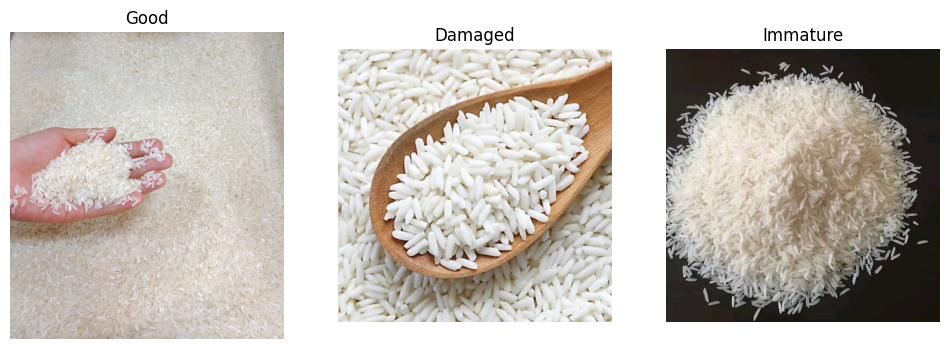

In [ ]:
# ========== 7. TAMPILKAN CONTOH FOTO ==========
import matplotlib.pyplot as plt
import random

print("\nContoh Foto dari Tiap Kelas:")

kelas = ['Good', 'Damaged', 'Immature']
plt.figure(figsize=(12,4))

for i, k in enumerate(kelas):
    # ambil 1 foto random dari tiap folder
    foto_list = os.listdir(f'/content/data/{k}')
    foto = random.choice(foto_list)
    img_path = f'/content/data/{k}/{foto}'

    # baca dan tampilkan
    img = plt.imread(img_path)
    plt.subplot(1, 3, i+1)
    plt.imshow(img)
    plt.title(k)
    plt.axis('off')

plt.show()